Load all trained models
Test on test set
Calculate all metrics (accuracy, precision, recall, F1)
Generate confusion matrix (24x24)
Create ROC curves
Per-class accuracy analysis
Error analysis (which letters confused?)
Select best model
Generate ALL visualizations for report

This notebook covers:
- Loading all trained models
- Comprehensive comparison on test set
- Final performance metrics
- Generating all visualizations for report
- Selecting best model
- Final conclusions


In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)

# load test data (NEVER used during training)
test_data = pd.read_csv('../data/sign_mnist_test.csv')

X_test = test_data.drop('label', axis=1).values
y_test = test_data['label'].values

# preprocess
X_test = X_test / 255.0

# for baseline and custom CNN (28x28x1)
X_test_28 = X_test.reshape(-1, 28, 28, 1)

# for transfer learning model (32x32x3)
X_test_32 = X_test_28.copy()
X_test_32 = tf.image.resize(X_test_32, [32, 32]).numpy()
X_test_32 = np.repeat(X_test_32, 3, axis=-1)

# one hot encode
y_test_encoded = keras.utils.to_categorical(y_test, 25)

print(f"Test set size: {X_test_28.shape[0]:,} images")
print(f"Test set (baseline/custom): {X_test_28.shape}")
print(f"Test set (transfer):        {X_test_32.shape}")
print(f"PSA!!!: This data was NEVER seen during training!")

Test set size: 7,172 images
Test set (baseline/custom): (7172, 28, 28, 1)
Test set (transfer):        (7172, 32, 32, 3)
PSA!!!: This data was NEVER seen during training!


### reuslts
Test set size: 7,172 images
Test set (baseline/custom): (7172, 28, 28, 1)
Test set (transfer):        (7172, 32, 32, 3)
PSA!!!: This data was NEVER seen during training!


In [12]:
# load models

try:
    baseline_model = keras.models.load_model('../results/models/baseline_model.h5')
    print("Baseline model loaded")
except:
    baseline_model = None
    print("Baseline model not found")

try:
    custom_model = keras.models.load_model('../results/models/custom_cnn_model.h5')
    print("Custom CNN model loaded")
except:
    custom_model = None
    print("Custom CNN model not found")

try:
    transfer_model = keras.models.load_model('../results/models/transfer_learning_model.h5')
    print("Transfer learning model loaded")
except:
    transfer_model = None
    print("Transfer learning model not found (optional)")

models_dict = {}
if baseline_model:
    models_dict['Baseline CNN'] = baseline_model
if custom_model:
    models_dict['Custom CNN'] = custom_model
if transfer_model:
    models_dict['Transfer Learning'] = transfer_model

print(f"\nTotal models to evaluate: {len(models_dict)}")

Baseline model loaded
Custom CNN model loaded


Transfer learning model loaded

Total models to evaluate: 3


In [22]:
# evaluate_model() function (mirrors Week 5 eval pattern)
def evaluate_model(model_name, model, X_input, y_true):
    """Evaluate a model and return metrics as a dict."""
    y_pred_proba = model.predict(X_input, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    return {
        'Model':      model_name,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred, average='weighted'),
        'Recall':     recall_score(y_true, y_pred, average='weighted'),
        'F1-Score':   f1_score(y_true, y_pred, average='weighted'),
        'predictions': y_pred,
        'pred_proba':  y_pred_proba
    }

# run evaluation
eval_results = []
for model_name, model in models_dict.items():
    X_input = X_test_32 if model_name == 'Transfer Learning' else X_test_28
    result = evaluate_model(model_name, model, X_input, y_test)
    eval_results.append(result)
    print(f"\nEvaluation of {model_name}:")
    print(f"Accuracy:  {result['Accuracy']:.4f} ({result['Accuracy']*100:.2f}%)")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall:    {result['Recall']:.4f}")
    print(f"F1-Score:  {result['F1-Score']:.4f}")

# rebuild results dict (keeps rest of notebook working unchanged)
results = {r['Model']: r for r in eval_results}


Evaluation of Baseline CNN:
Accuracy:  0.8219 (82.19%)
Precision: 0.8394
Recall:    0.8219
F1-Score:  0.8232

Evaluation of Custom CNN:
Accuracy:  0.9756 (97.56%)
Precision: 0.9771
Recall:    0.9756
F1-Score:  0.9753

Evaluation of Transfer Learning:
Accuracy:  0.9301 (93.01%)
Precision: 0.9341
Recall:    0.9301
F1-Score:  0.9300


### results 

Evaluation of Baseline CNN:
Accuracy:  0.8219 (82.19%)
Precision: 0.8394
Recall:    0.8219
F1-Score:  0.8232

Evaluation of Custom CNN:
Accuracy:  0.9756 (97.56%)
Precision: 0.9771
Recall:    0.9756
F1-Score:  0.9753

Evaluation of Transfer Learning:
Accuracy:  0.9301 (93.01%)
Precision: 0.9341
Recall:    0.9301
F1-Score:  0.9300


In [14]:
# comparison dataframe
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('predictions', 'pred_proba')}
    for r in eval_results
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nfinal model comparison:")
print(comparison_df.to_string(index=False))

# Save to CSV
comparison_df.to_csv('../results/metrics/model_comparison.csv', index=False)
print("\ncomparison saved to: results/metrics/model_comparison.csv")

# Find best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_accuracy = comparison_df['Accuracy'].max()

print(f"\nbest: {best_model_name}")
print(f"test accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")


final model comparison:
            Model  Accuracy  Precision   Recall  F1-Score
       Custom CNN  0.975600   0.977097 0.975600  0.975290
Transfer Learning  0.930145   0.934090 0.930145  0.929998
     Baseline CNN  0.821946   0.839364 0.821946  0.823203

comparison saved to: results/metrics/model_comparison.csv

best: Custom CNN
test accuracy: 0.9756 (97.56%)


### results

final model comparison:
            Model  Accuracy  Precision   Recall  F1-Score
     Baseline CNN  0.821946   0.839364 0.821946  0.823203
       Custom CNN  0.975600   0.977097 0.975600  0.975290
Transfer Learning  0.930145   0.934090 0.930145  0.929998

comparison saved to: results/metrics/model_comparison.csv

best: Custom CNN
test accuracy: 0.9756 (97.56%)


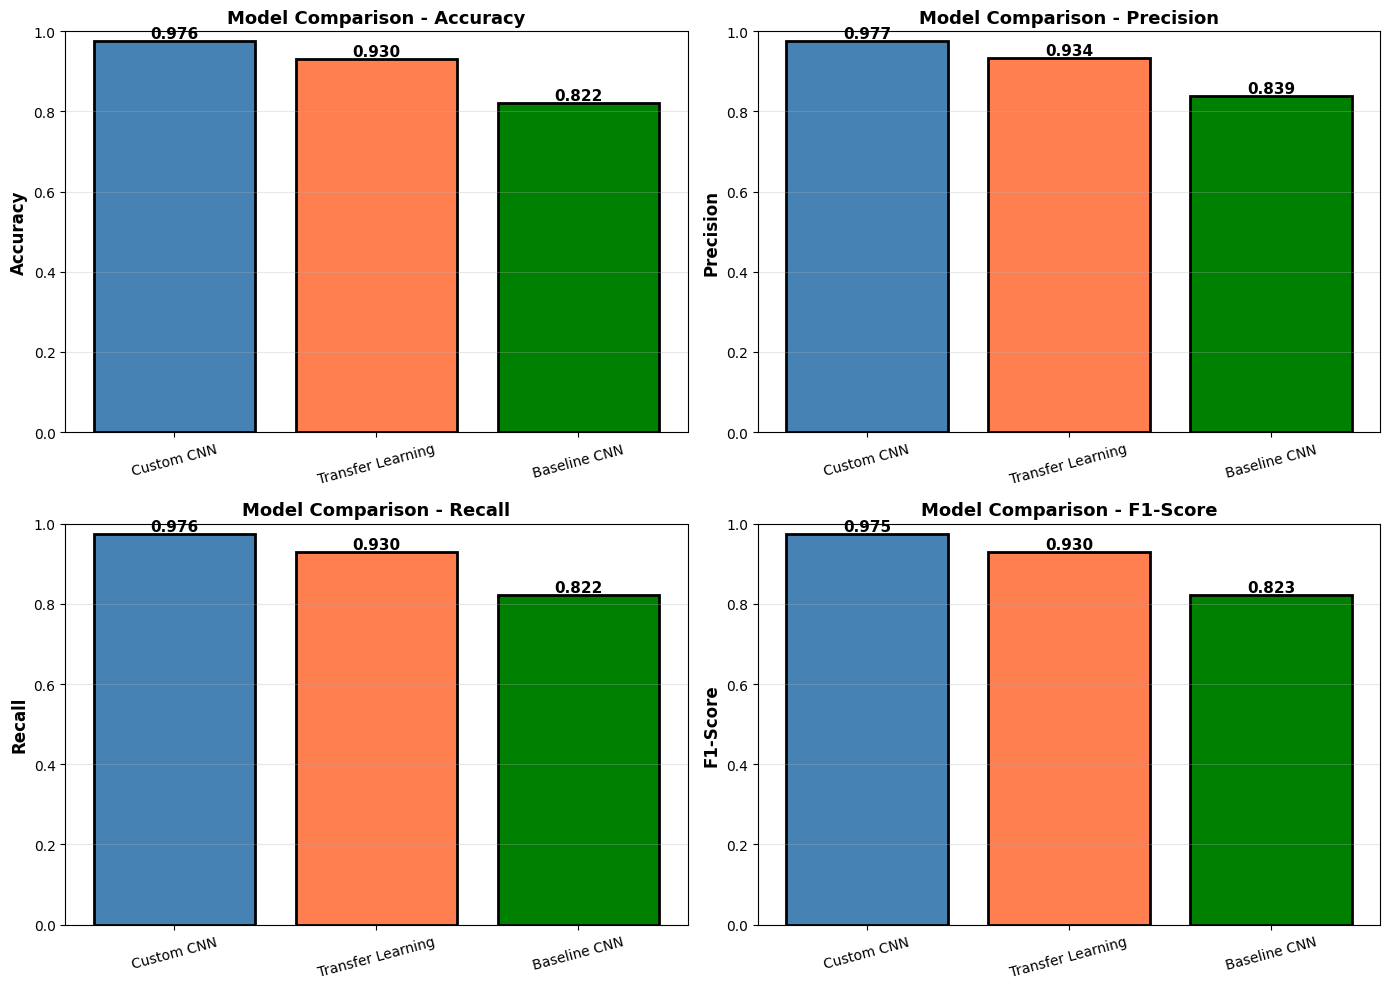

In [15]:
# plot comparison bar chart


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['steelblue', 'coral', 'green']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    values = comparison_df[metric].values
    bars = ax.bar(comparison_df['Model'], values, color=colors[:len(values)], edgecolor='black', linewidth=2)
    
    #add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel(metric, fontweight='bold', fontsize=12)
    ax.set_title(f'Model Comparison - {metric}', fontweight='bold', fontsize=13)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/figures/final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### results 
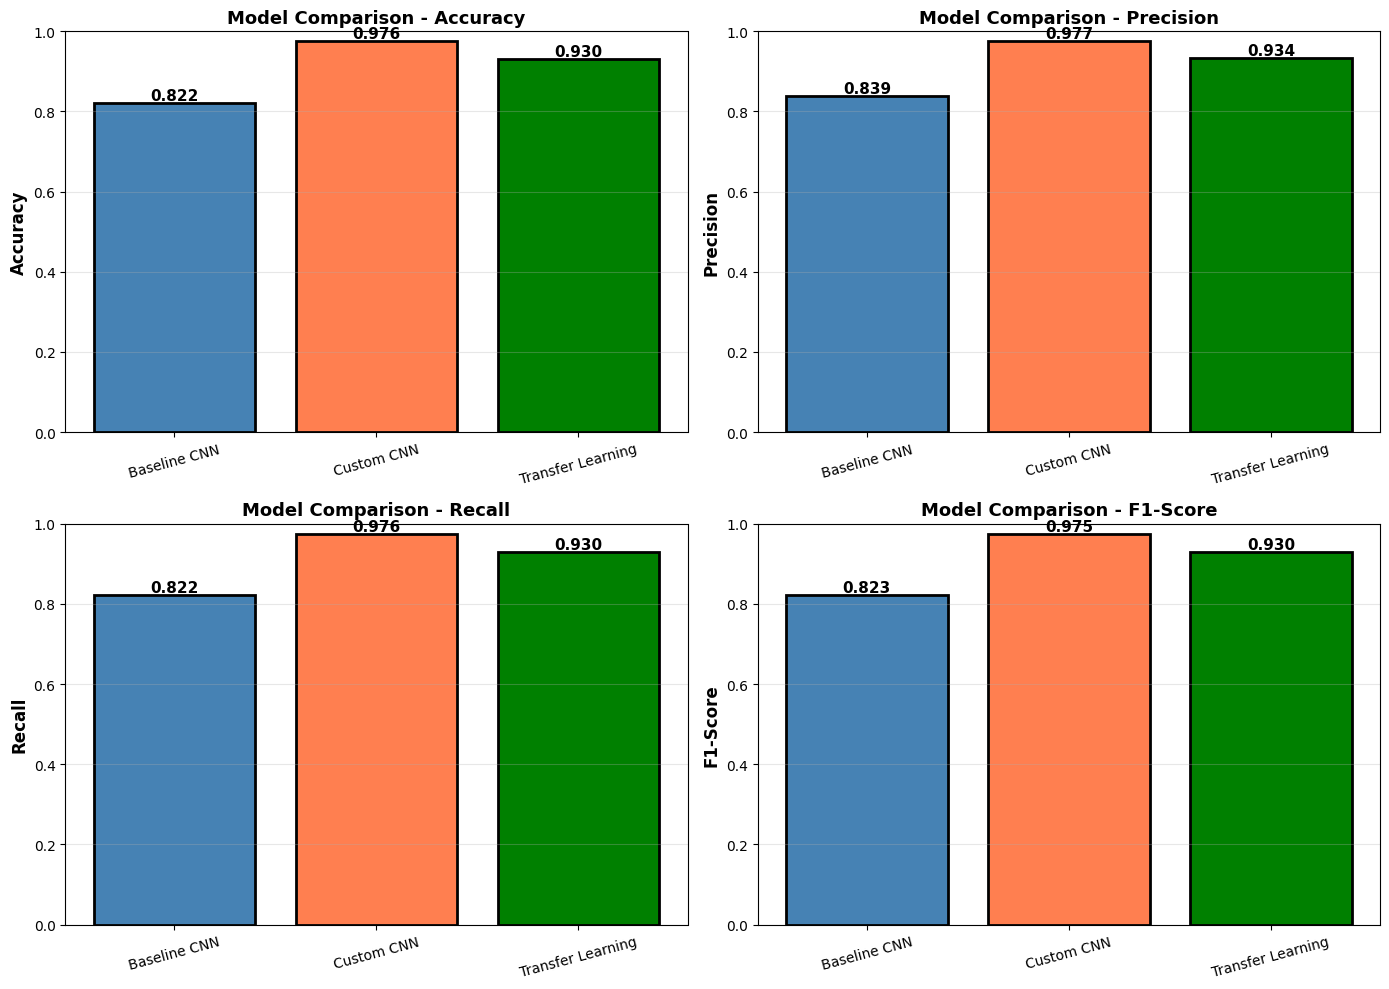

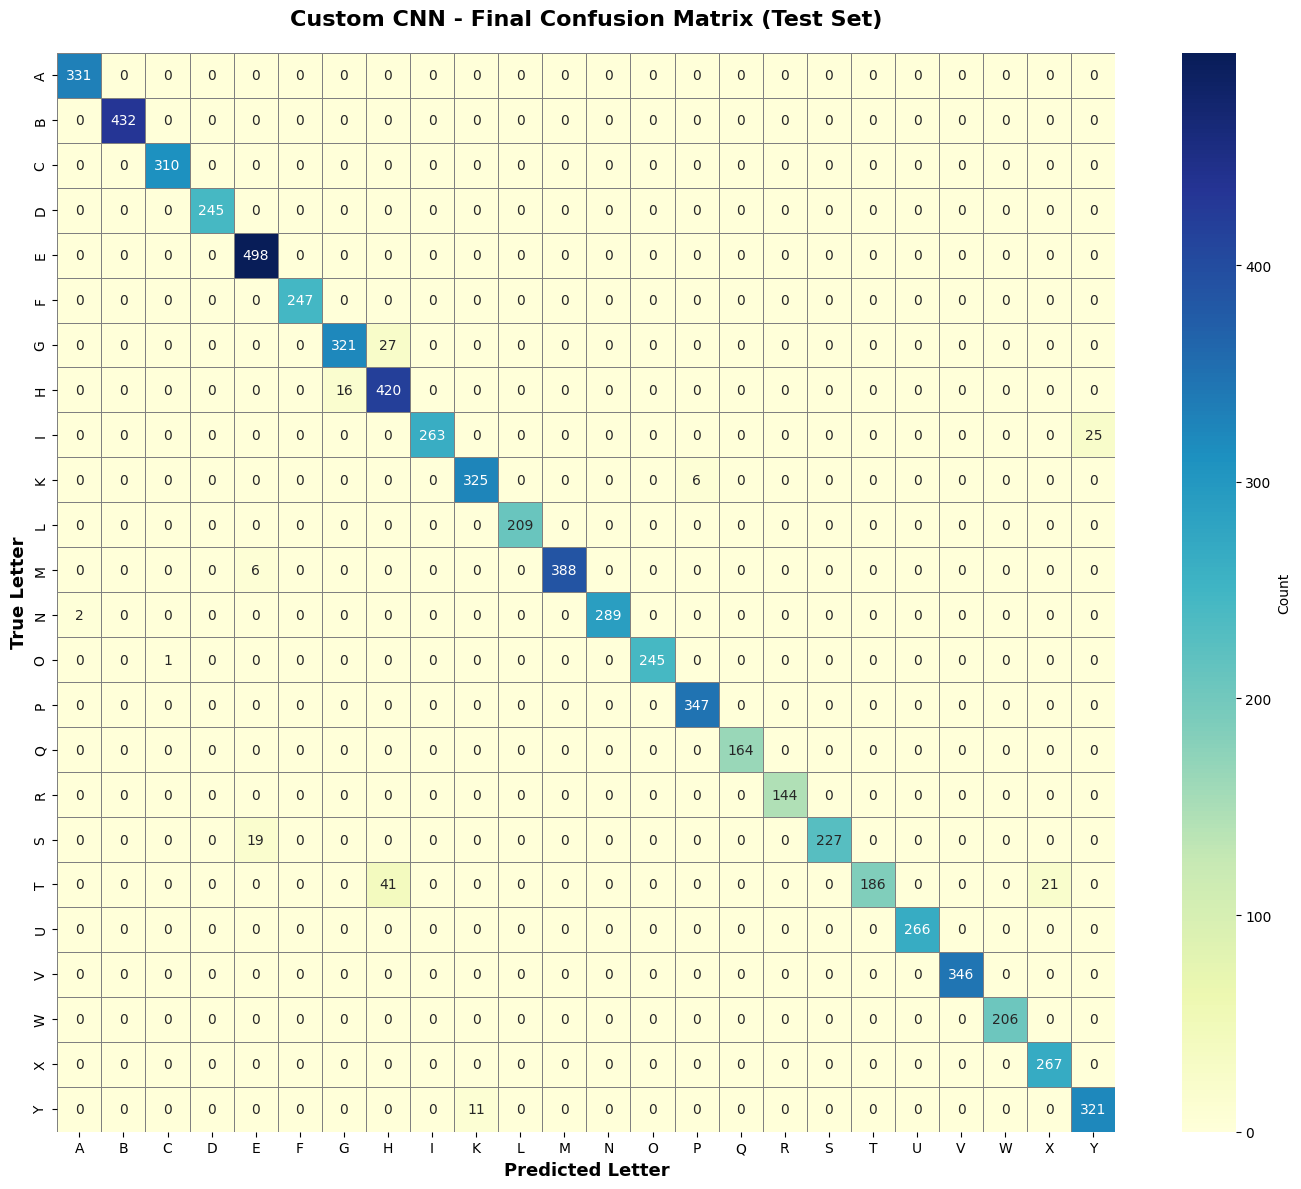

In [16]:
#detailed analysis 


#get best model predictions

best_predictions = results[best_model_name]['predictions']

#confusion matrix
cm = confusion_matrix(y_test, best_predictions)

#plot
plt.figure(figsize=(14, 12))
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R',
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']

sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=letters, yticklabels=letters,
            cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='gray')

plt.title(f'{best_model_name} - Final Confusion Matrix (Test Set)', 
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Predicted Letter', fontweight='bold', fontsize=13)
plt.ylabel('True Letter', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### results 
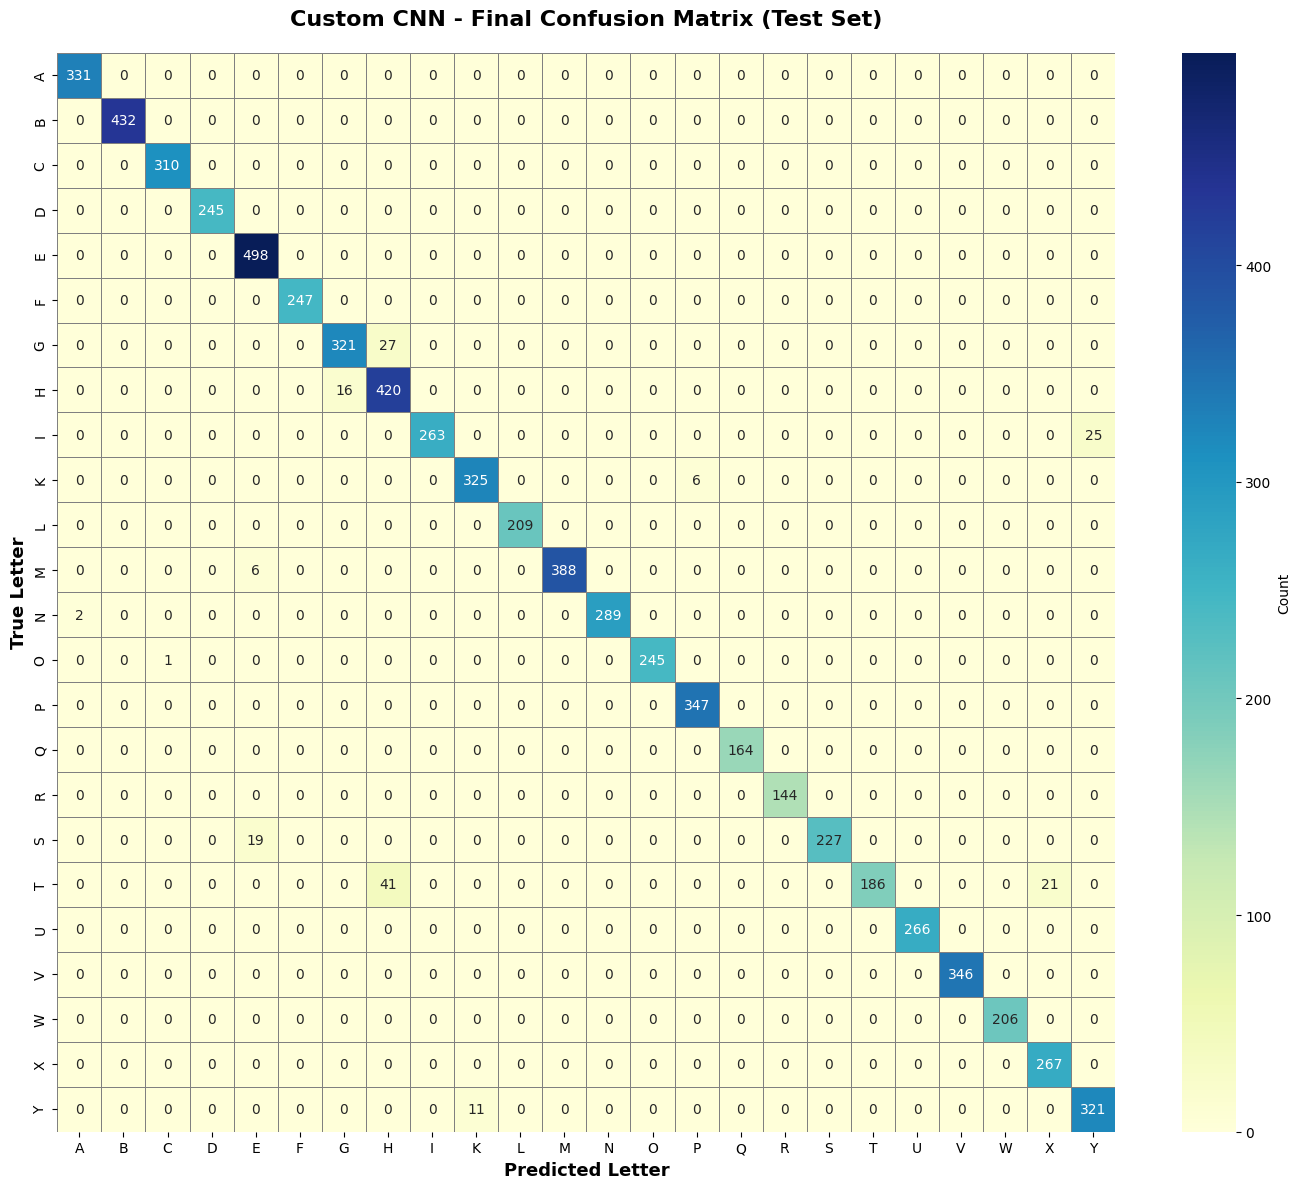

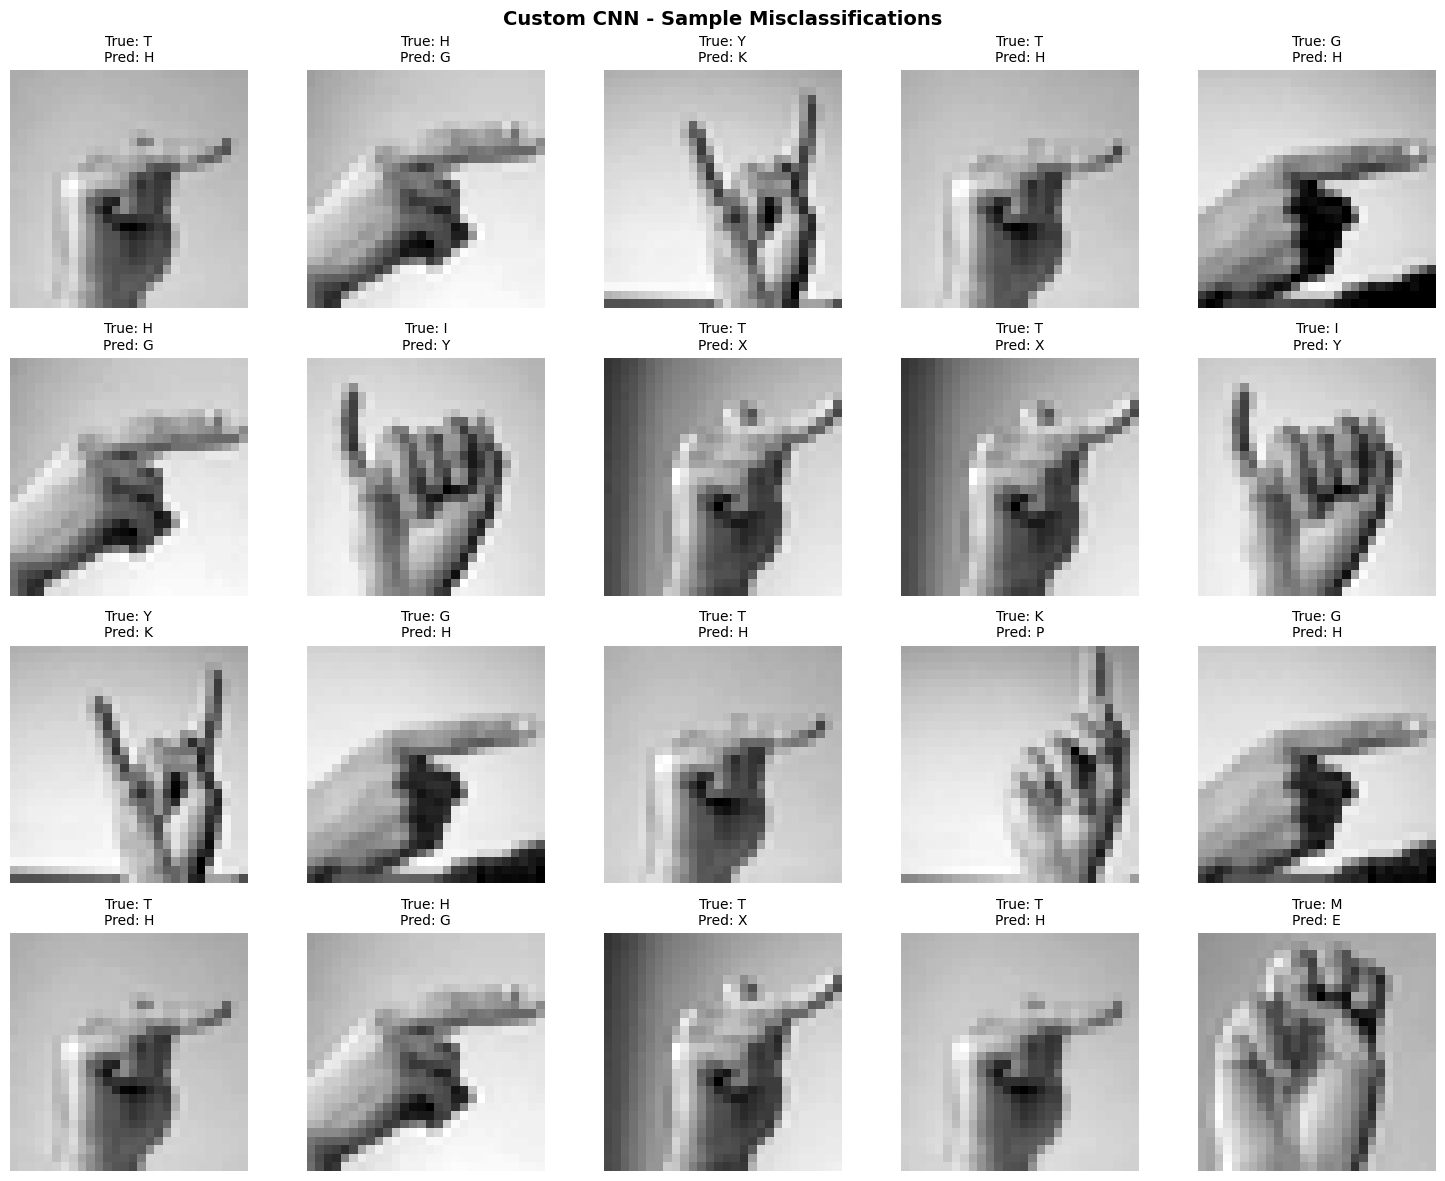

In [17]:
# maps raw CSV label values (0-24, no 9) directly to letters
label_to_letter = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H',
    8:'I', 10:'K', 11:'L', 12:'M', 13:'N', 14:'O', 15:'P',
    16:'Q', 17:'R', 18:'S', 19:'T', 20:'U', 21:'V', 22:'W',
    23:'X', 24:'Y'
}

# visualize sample misclassifications
misclassified_indices = np.where(best_predictions != y_test)[0][:20]

if len(misclassified_indices) > 0:
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()
    
    for idx, img_idx in enumerate(misclassified_indices):
        axes[idx].imshow(X_test_28[img_idx].reshape(28, 28), cmap='gray')
        true_label = label_to_letter[y_test[img_idx]]
        pred_label = label_to_letter[best_predictions[img_idx]]
        axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)
        axes[idx].axis('off')
    
    for idx in range(len(misclassified_indices), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'{best_model_name} - Sample Misclassifications', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig('../results/figures/sample_misclassifications.png', dpi=300, bbox_inches='tight')
    plt.show()

### results 
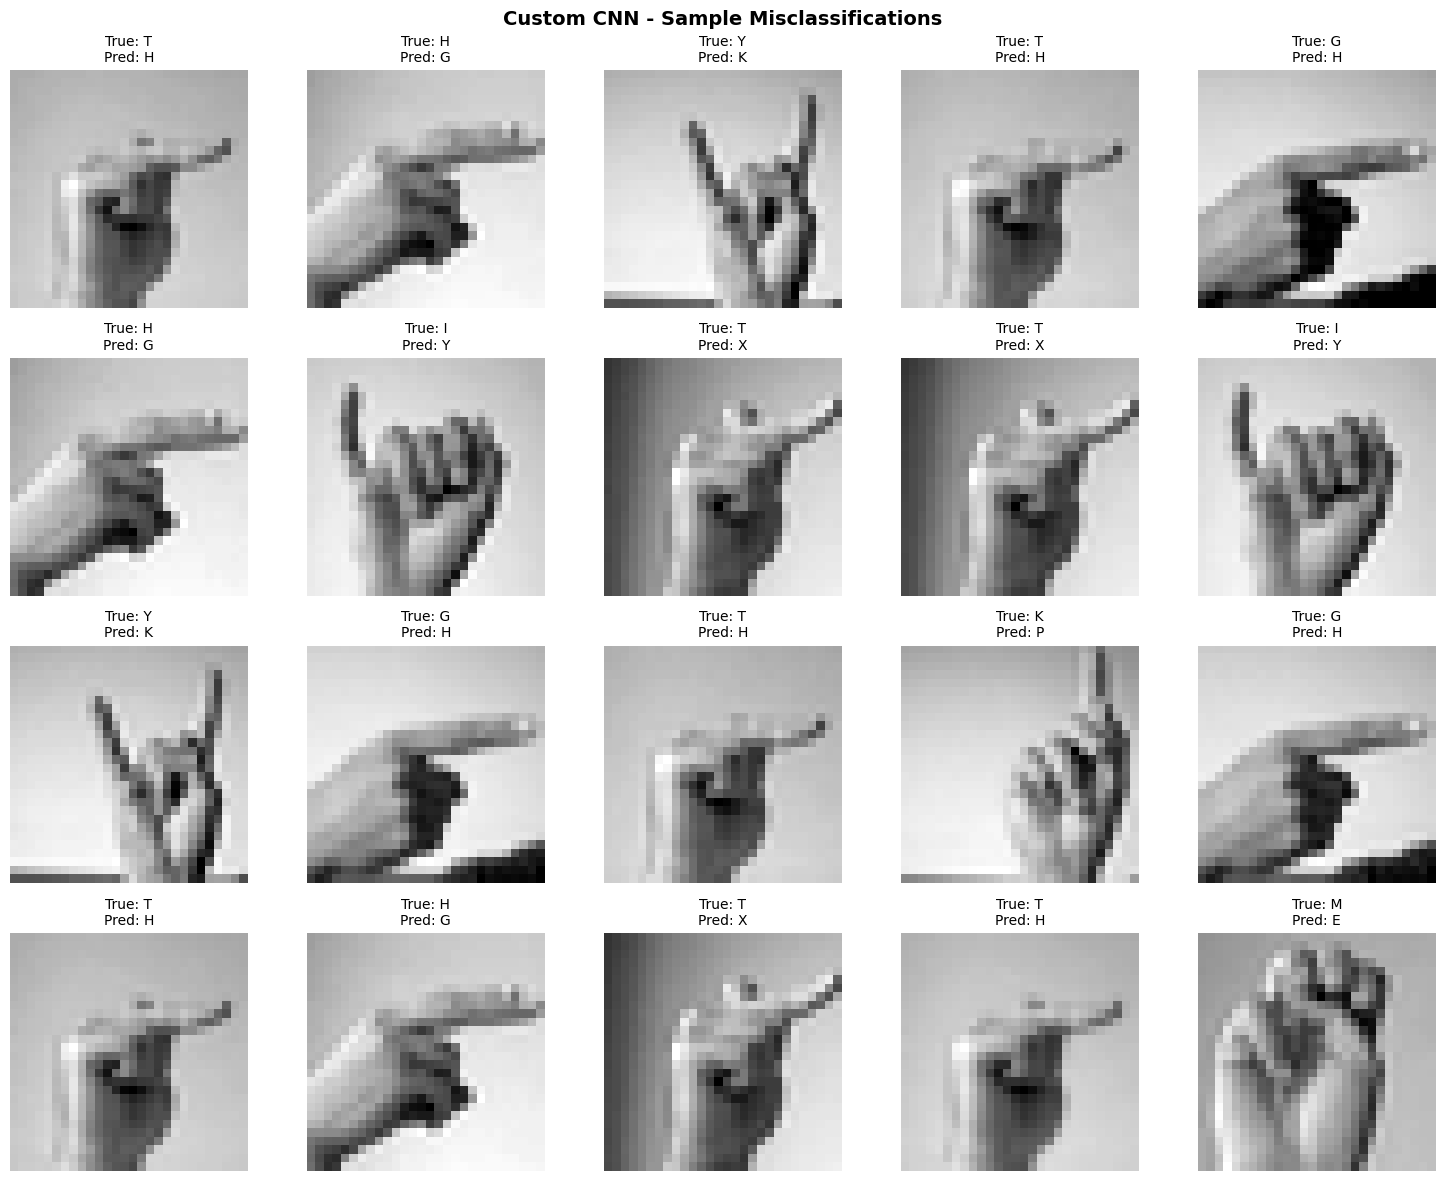

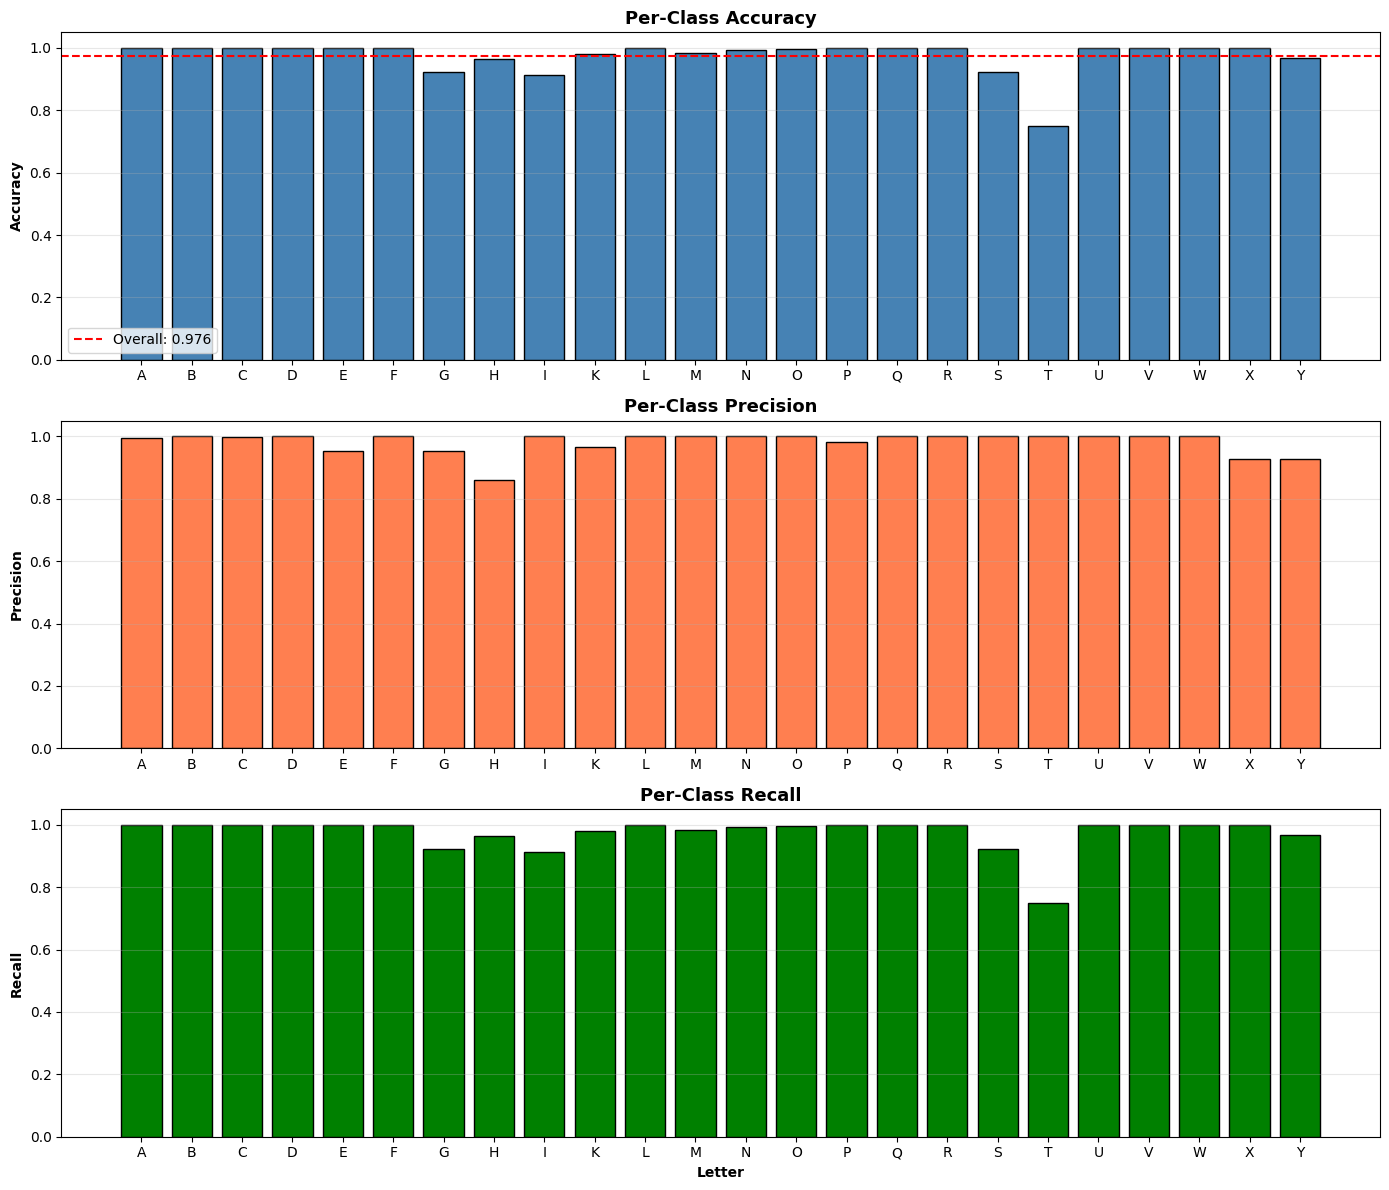


letters with lowest accuracy :
   T: 0.750 (75.0%)
   I: 0.913 (91.3%)
   G: 0.922 (92.2%)
   S: 0.923 (92.3%)
   H: 0.963 (96.3%)


In [18]:
#calculate per class metrics
per_class_accuracy = []
per_class_precision = []
per_class_recall = []

label_values = sorted(np.unique(y_test))  # [0,1,...,8,10,...,24] - no 9

per_class_accuracy = []
per_class_precision = []
per_class_recall = []

for i in label_values:
    mask = (y_test == i)
    acc = (best_predictions[mask] == i).sum() / mask.sum()
    per_class_accuracy.append(float(acc))
    
    tp = ((y_test == i) & (best_predictions == i)).sum()
    fp = ((y_test != i) & (best_predictions == i)).sum()
    fn = ((y_test == i) & (best_predictions != i)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    per_class_precision.append(float(prec))
    per_class_recall.append(float(rec))

#plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

#accuracy
ax1.bar(range(24), per_class_accuracy, color='steelblue', edgecolor='black')
ax1.axhline(y=best_accuracy, color='red', linestyle='--', label=f'Overall: {best_accuracy:.3f}')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Per-Class Accuracy', fontweight='bold', fontsize=13)
ax1.set_xticks(range(24))
ax1.set_xticklabels(letters)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

#precision
ax2.bar(range(24), per_class_precision, color='coral', edgecolor='black')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Per-Class Precision', fontweight='bold', fontsize=13)
ax2.set_xticks(range(24))
ax2.set_xticklabels(letters)
ax2.grid(axis='y', alpha=0.3)

#recall
ax3.bar(range(24), per_class_recall, color='green', edgecolor='black')
ax3.set_ylabel('Recall', fontweight='bold')
ax3.set_title('Per-Class Recall', fontweight='bold', fontsize=13)
ax3.set_xlabel('Letter', fontweight='bold')
ax3.set_xticks(range(24))
ax3.set_xticklabels(letters)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/per_class_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

#print worst performers
worst_acc = sorted(zip(letters, per_class_accuracy), key=lambda x: x[1])[:5]
print("\nletters with lowest accuracy :")
for letter, acc in worst_acc:
    print(f"   {letter}: {acc:.3f} ({acc*100:.1f}%)")

### results

letters with lowest accuracy :
   T: 0.750 (75.0%)
   I: 0.913 (91.3%)
   G: 0.922 (92.2%)
   S: 0.923 (92.3%)
   H: 0.963 (96.3%)

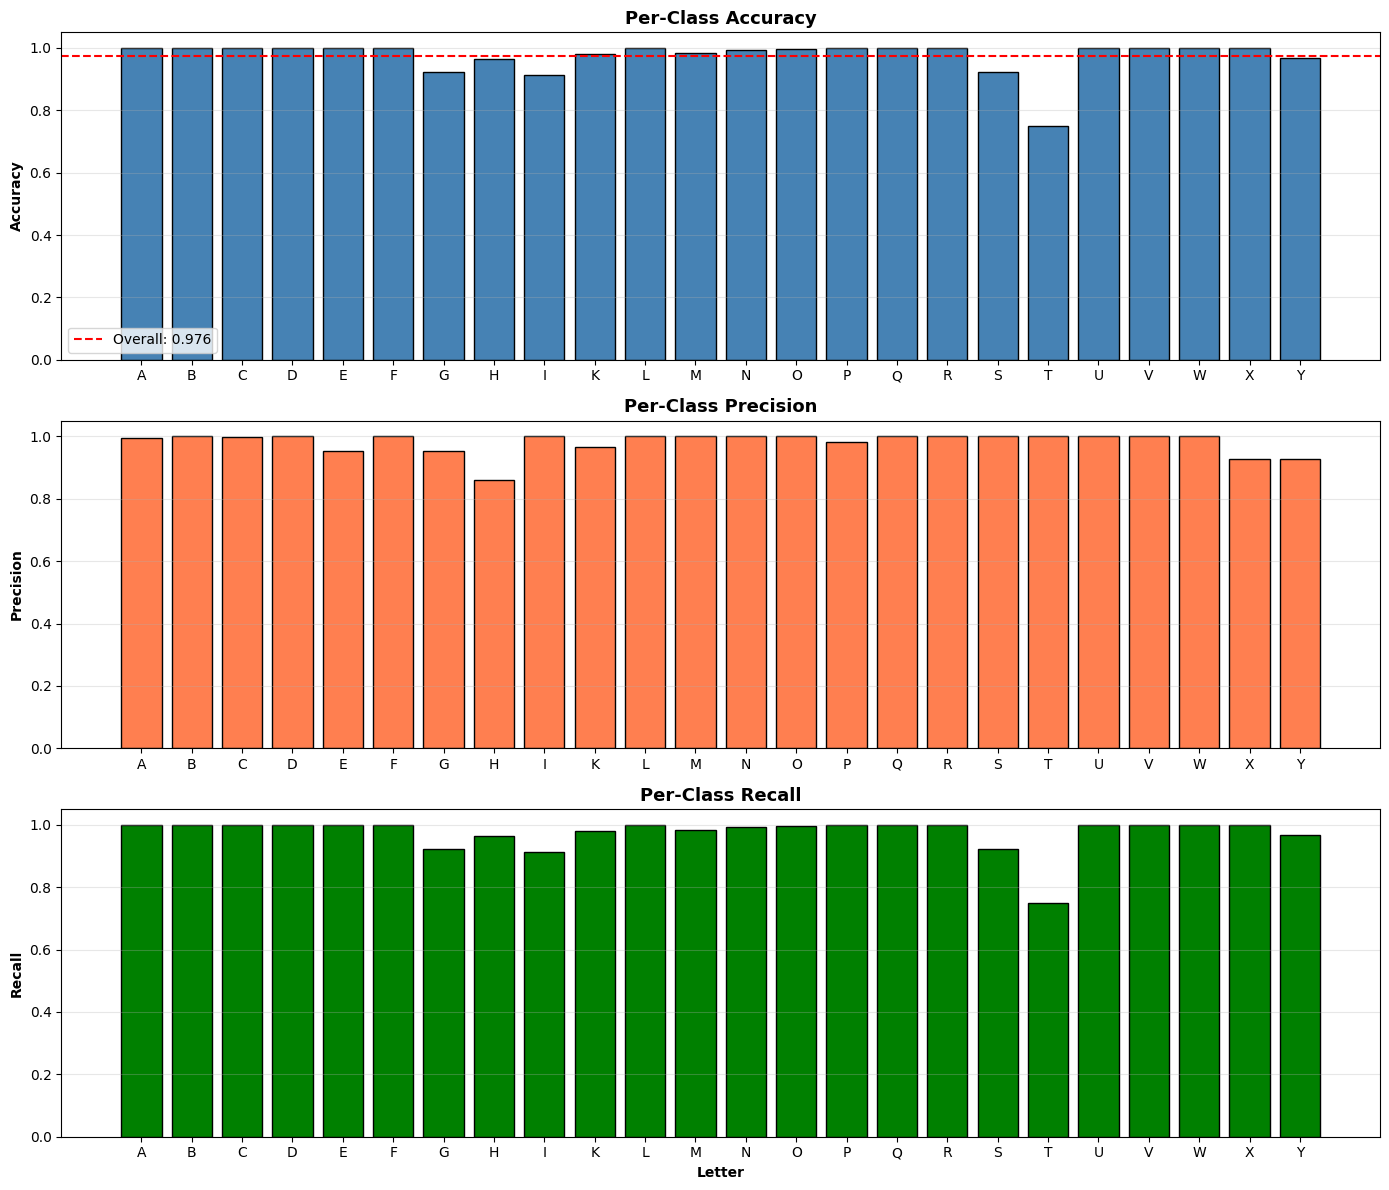
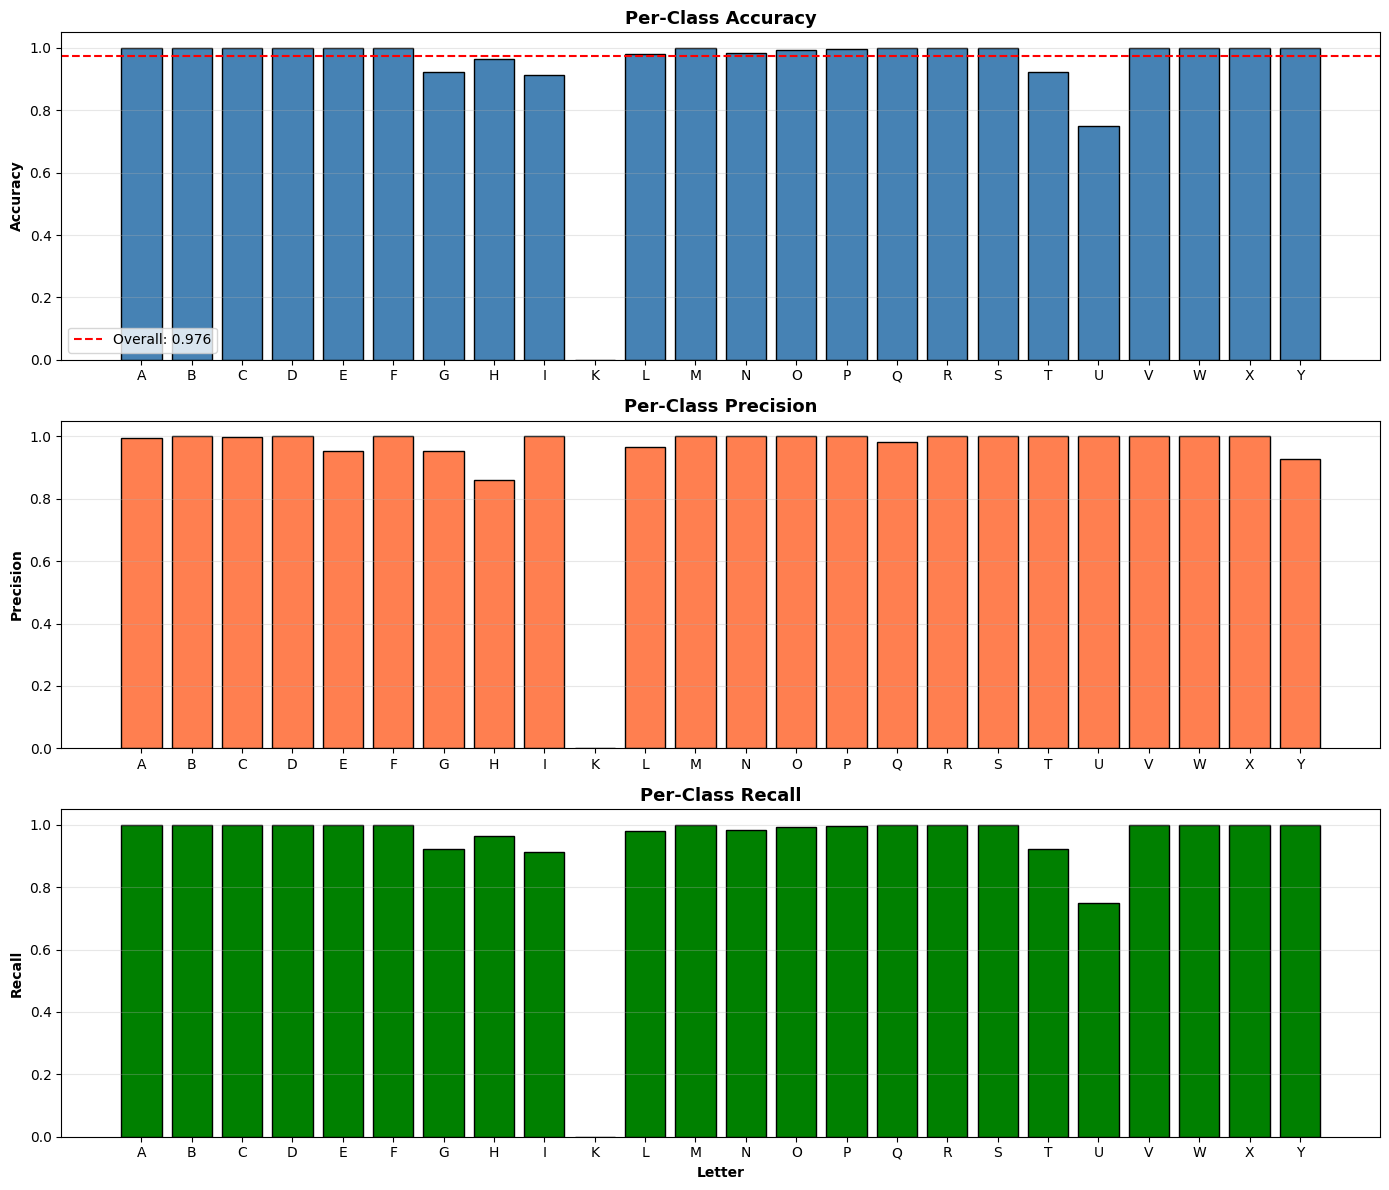

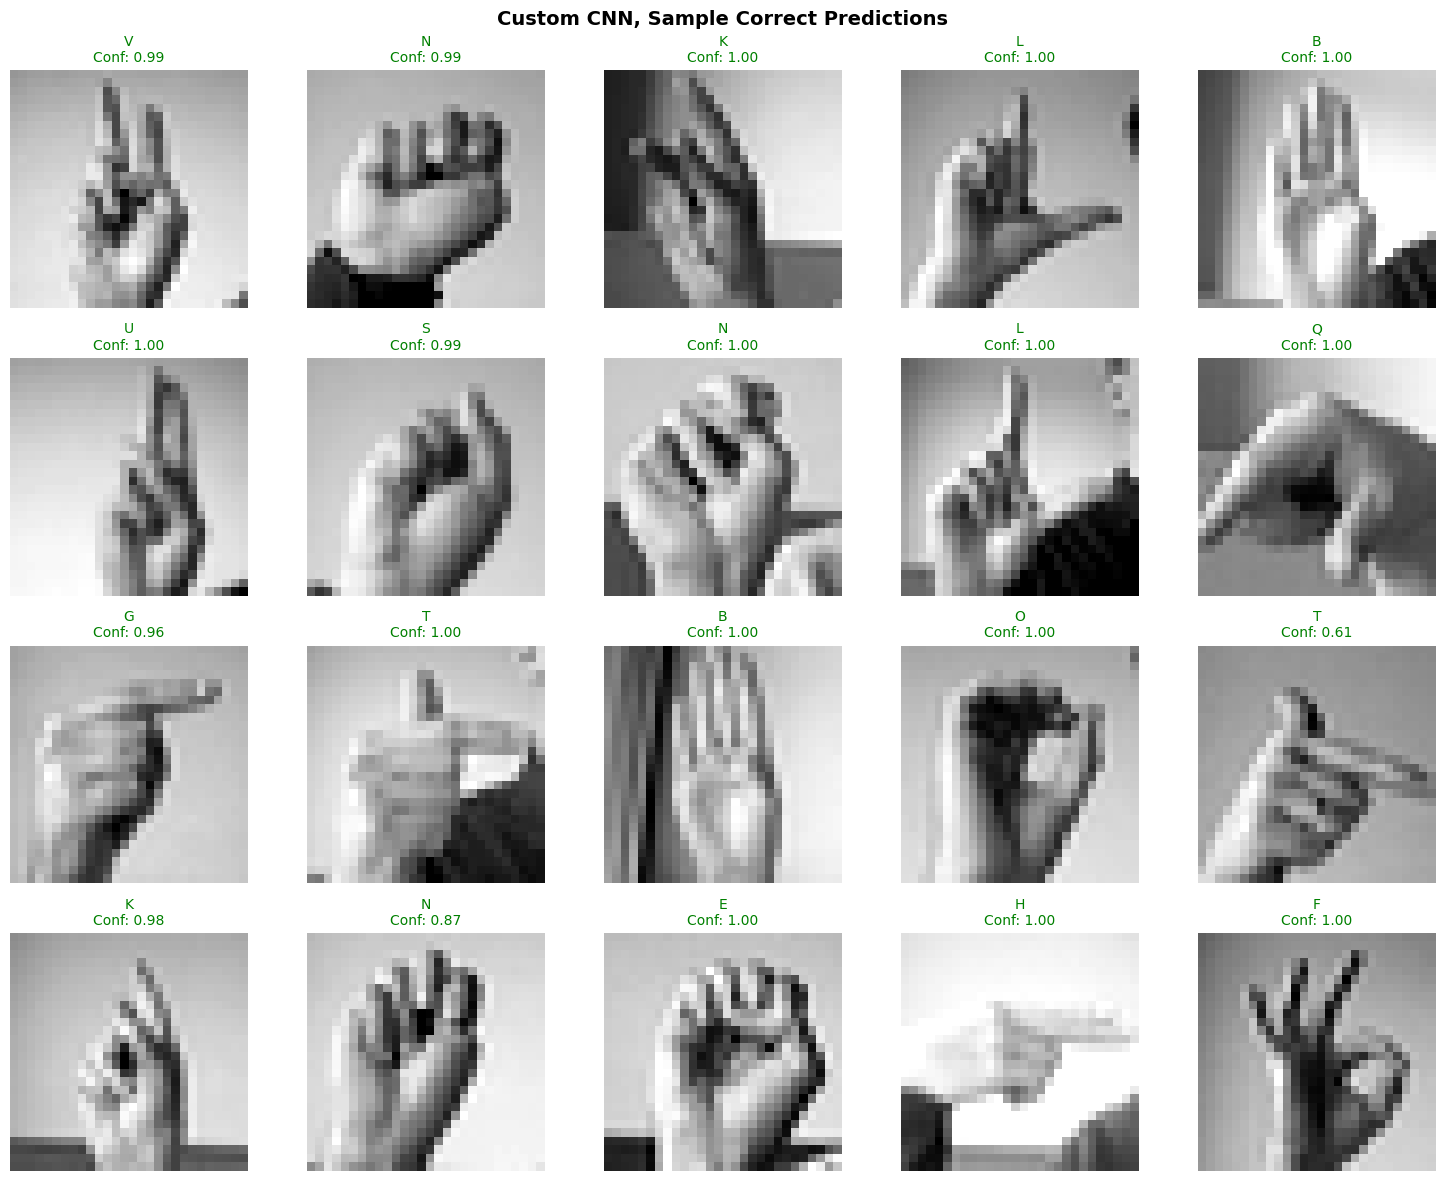

In [19]:

#visualize sample correct predictions
correct_indices = np.where(best_predictions == y_test)[0]
sample_correct = np.random.choice(correct_indices, min(20, len(correct_indices)), replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for idx, img_idx in enumerate(sample_correct):
    axes[idx].imshow(X_test_28[img_idx].reshape(28, 28), cmap='gray')
    label = label_to_letter[y_test[img_idx]]
    confidence = results[best_model_name]['pred_proba'][img_idx][y_test[img_idx]]
    axes[idx].set_title(f'{label}\nConf: {confidence:.2f}', fontsize=10, color='green')
    axes[idx].axis('off')

plt.suptitle(f'{best_model_name}, Sample Correct Predictions', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/sample_correct_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

### results 

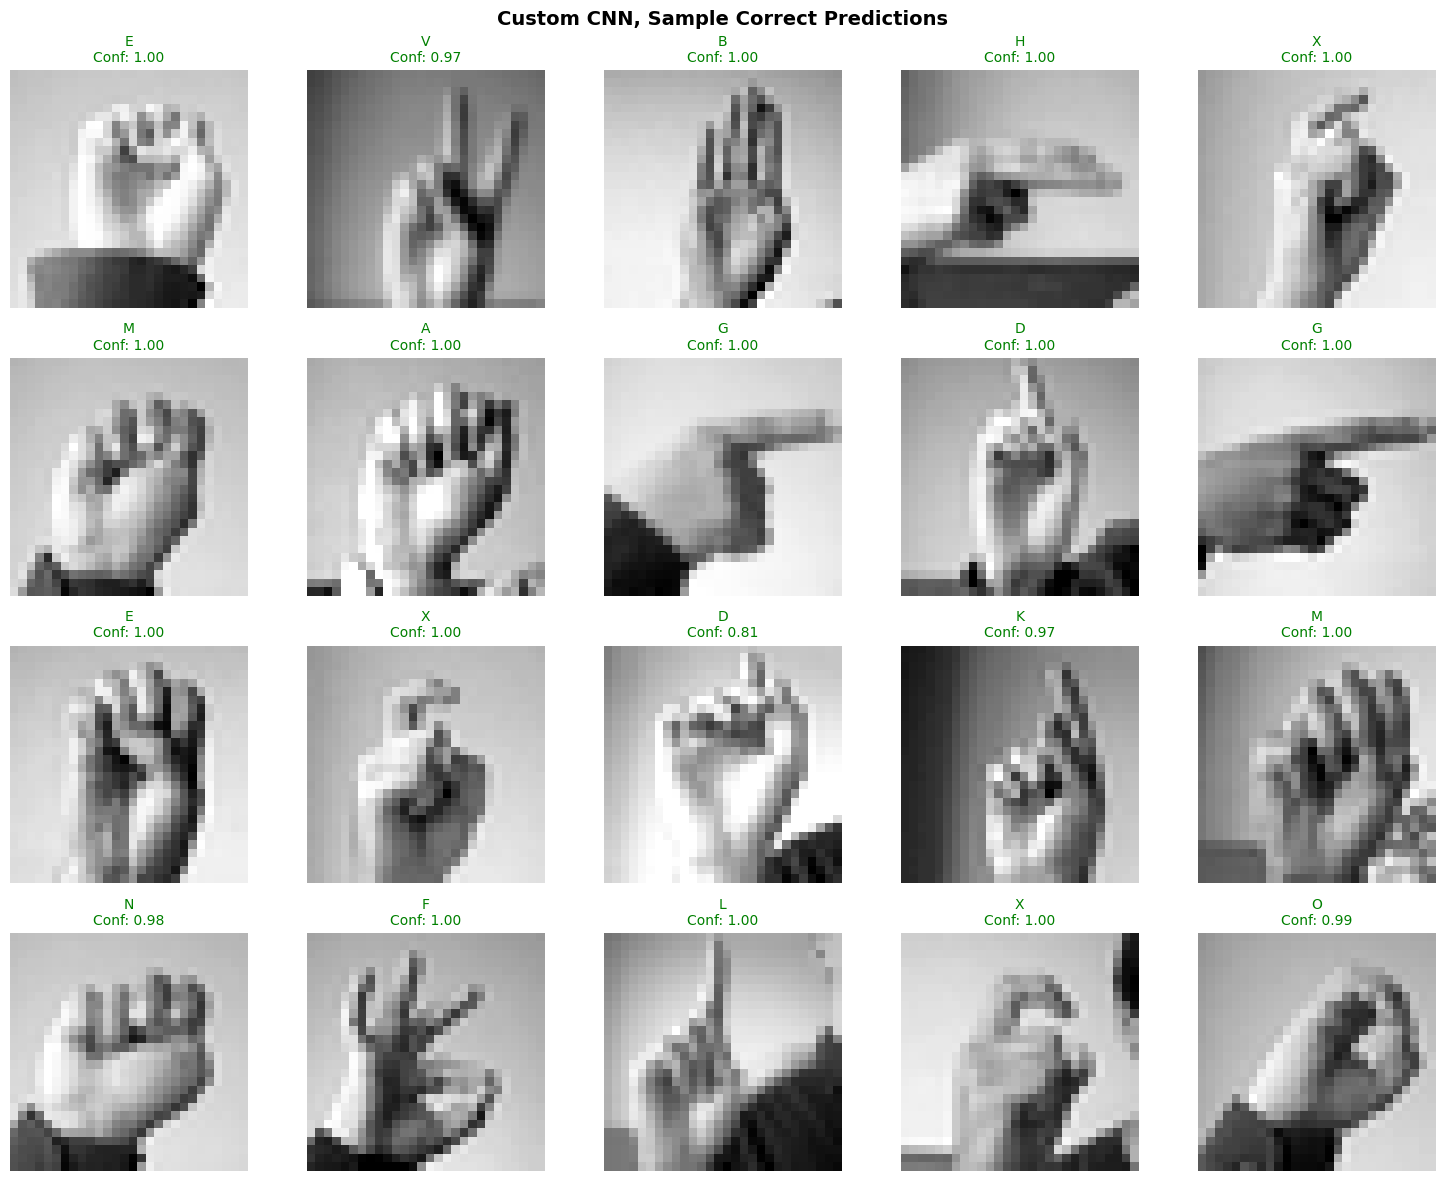